In [11]:
# Imports
import torch
import gpytorch
import numpy as np
#import scienceplots
import matplotlib.pyplot as plt
#plt.style.use(["science", "no-latex"])
from abc import ABC, abstractmethod
from enum import Enum
from typing import Optional
from scipy.interpolate import interp1d

# Clear any old variables, similar to clear all, close all in MATLAB
torch.manual_seed(42)

In [12]:
# Generate Perturbation objects
class PerturbationStatus(Enum):
    """
    Document type of active perturbation.
    0 := Thruster fully operational
    1 := Thruster is stuck off
    2 := Thruster is stuck on
    3 := Thruster is experiencing a different failure (sampled from a GP)
    """

    OPERATIONAL = 0
    STUCK_OFF = 1
    STUCK_ON = 2
    SAMPLE_PERTURBATION = 3
    FAULTY_VALVE = 4


class Perturbation(ABC):
    """
    Base class for all perturbations applied to the model.
    Perturbations are defined as changes to the model's
    dynamics such as a mismatch between desired thrust versus
    actual thrust.
    """

    def __init__(self, model_config) -> None:
        # Extract the number of thrusters
        self.nu = 12

        # Thruster mask to document the operational status of thrusters
        self.thruster_mask = np.full(self.nu, PerturbationStatus.OPERATIONAL)

    def select_thruster(self, index: Optional[int]) -> int:
        """
        Return index if one is provided, randomly select one of the working thrusters otherwise.
        """
        if isinstance(index, int):
            return index
        else:
            working_thrusters = np.where(
                self.thruster_mask == PerturbationStatus.OPERATIONAL
            )[0]
            random_index = np.random.choice(working_thrusters)
            return random_index

    @abstractmethod
    def apply(self, input: np.ndarray, timestamp: Optional[float] = None) -> np.ndarray:
        pass

    @abstractmethod
    def key_callback(self, keycode: Optional[int] = None) -> None:
        pass


# Create a Perturbation object
class FaultyValve(Perturbation):
    def __init__(self, model_config) -> None:
        super().__init__(model_config)

        self.failure_type = PerturbationStatus.FAULTY_VALVE
        self.start_times = np.zeros(self.nu)

        # Store interpolation functions for each thruster
        self.interpolations = [None] * self.nu

    def apply(
        self, input: np.ndarray, timestamp: Optional[float] = None
    ) -> np.ndarray:
        # Do a elementwise AND operation
        faulty = np.logical_and(
            self.thruster_mask == PerturbationStatus.FAULTY_VALVE,
            timestamp >= self.start_times,
        )

        # Apply interpolation only to the affected thrusters with active perturbations
        if np.any(faulty):
            # Gather input values for the affected thrusters
            affected_inputs = input[faulty]

            # Apply the respective interpolation functions
            interpolated_values = np.array([
                self.interpolations[i](affected_inputs[idx])
                for idx, i in enumerate(np.where(faulty)[0])
            ])

            # Update the input array with interpolated values
            input[faulty] = interpolated_values

        return input

    def register_perturbation(
        self,
        index: Optional[int] = None,
        start_time: Optional[float] = 0.0,
        x_data: np.ndarray = None,
        y_data: np.ndarray = None,
    ) -> None:
        """
        Register a perturbation and store the interpolation data.
        """
        thruster_index = self.select_thruster(index)
        self.thruster_mask[thruster_index] = PerturbationStatus.FAULTY_VALVE
        self.start_times[thruster_index] = start_time

        # Create the interpolation function for the affected thruster
        self.interpolations[thruster_index] = interp1d(
            x_data, y_data, kind='linear', fill_value="extrapolate"
        )

        print(
            f"Thruster {thruster_index} is affected by a faulty valve starting at {start_time} seconds."
        )

    def key_callback(self, keycode: Optional[int] = None) -> None:
        pass


In [13]:
# Custom class to define GP models for different failure types
class ThrusterFailureGPModel(gpytorch.models.ExactGP):
    def __init__(self, train_x, train_y, likelihood, kernel_type="RBF", lengthscale=0.2, outputscale=1.0):
        super(ThrusterFailureGPModel, self).__init__(train_x, train_y, likelihood)
        self.mean_module = gpytorch.means.ConstantMean()

        # Define different kernels for different failure modes
        if kernel_type == "RBF":
            self.covar_module = gpytorch.kernels.ScaleKernel(
                gpytorch.kernels.RBFKernel(lengthscale=lengthscale)
            )
        elif kernel_type == "Matern":
            self.covar_module = gpytorch.kernels.ScaleKernel(
                gpytorch.kernels.MaternKernel(nu=1.5, lengthscale=lengthscale)
            )

        # Set output scale for the kernel
        self.covar_module.outputscale = outputscale

    def forward(self, x):
        mean_x = self.mean_module(x)
        covar_x = self.covar_module(x)
        return gpytorch.distributions.MultivariateNormal(mean_x, covar_x)

In [14]:
## Function to generate data for different failure modes
def generate_failure_data(failure_type, num_points=100, valve_min=0.1, valve_max=0.5, upper_bound = 0.6):
    demanded_force = torch.linspace(0, upper_bound, num_points)  # Values between 0 and 1
    valve_max = 0.8 * upper_bound

    if failure_type == "Saturated Thrust":
        # Close to y=x from 0 to 0.5, then converge to ~0.5 after that
        actual_force = torch.where(demanded_force < 0.3 * upper_bound, 
                                   demanded_force, 
                                   0.3 * upper_bound + 0.1 * torch.randn_like(demanded_force) * (upper_bound - demanded_force))
    
    elif failure_type == "Faulty Valve":
        # Define thresholds
        lower_threshold = 0.67 * upper_bound
        upper_threshold = 0.73 * upper_bound

        # Piecewise linear: min value at lower_threshold, linear up to max value at upper_threshold
        actual_force = torch.zeros_like(demanded_force) + valve_min
        
        # Linear region between lower_threshold and upper_threshold
        linear_region = (demanded_force >= lower_threshold) & (demanded_force <= upper_threshold)
        actual_force[linear_region] = valve_min + ((demanded_force[linear_region] - lower_threshold) / 
                                                   (upper_threshold - lower_threshold)) * (valve_max - valve_min)
        
        # Max value for demanded_force > upper_threshold
        actual_force[demanded_force > upper_threshold] = valve_max
    
    elif failure_type == "Thrust Instability":
        # Oscillations in thrust due to instability
        actual_force = demanded_force - 0.1 * upper_bound * torch.sin(10 * demanded_force) + 0.05 * upper_bound * torch.randn_like(demanded_force)
    
    elif failure_type == "thermal_stress":
        # At high demanded forces, actual force decreases due to heat
        actual_force = demanded_force

    else:
        raise ValueError(f"Unknown failure type: {failure_type}")
    
    actual_force = torch.clamp(actual_force, 0, upper_bound)  # Ensure the values stay between 0 and 1
    return demanded_force, actual_force

# Function to sample from the GP
def sample_gp_function(gp_model, likelihood, demanded_force, num_samples=3):
    gp_model.eval()
    likelihood.eval()
    
    with torch.no_grad(), gpytorch.settings.fast_pred_var():
        observed_pred = gp_model(demanded_force)
    
    samples = observed_pred.sample(torch.Size([num_samples]))
    return samples


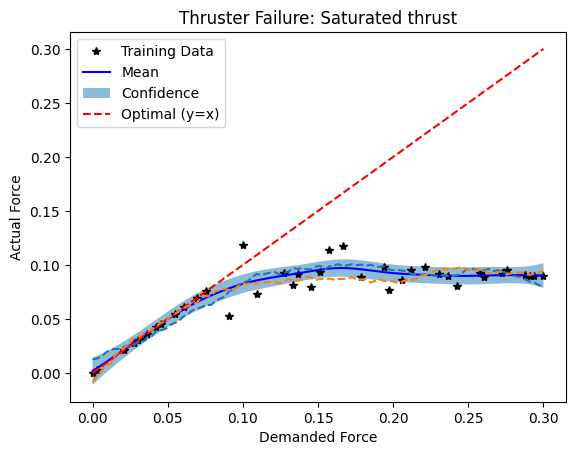

Thruster 2 is affected by a faulty valve starting at 5.0 seconds.
Thruster 3 is affected by a faulty valve starting at 6.0 seconds.


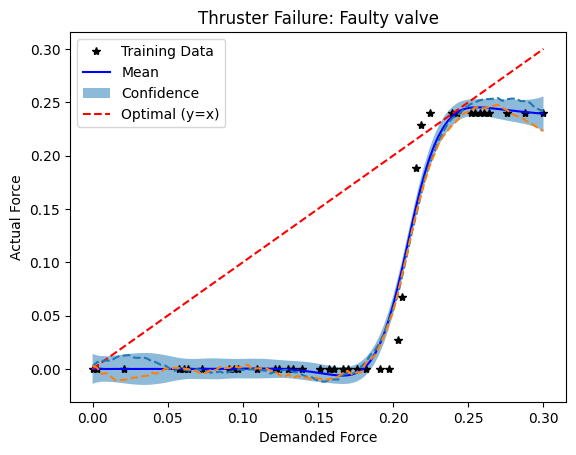

Thruster 2 is affected by a faulty valve starting at 5.0 seconds.
Thruster 3 is affected by a faulty valve starting at 6.0 seconds.


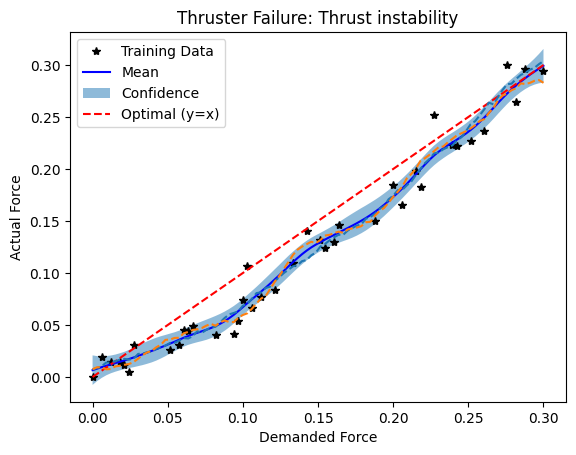

Thruster 2 is affected by a faulty valve starting at 5.0 seconds.
Thruster 3 is affected by a faulty valve starting at 6.0 seconds.


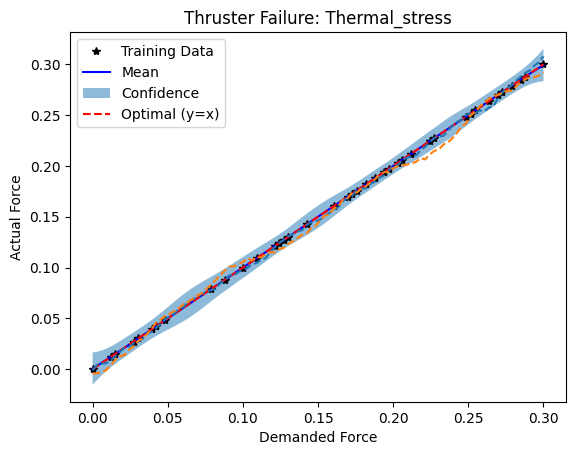

Thruster 2 is affected by a faulty valve starting at 5.0 seconds.
Thruster 3 is affected by a faulty valve starting at 6.0 seconds.


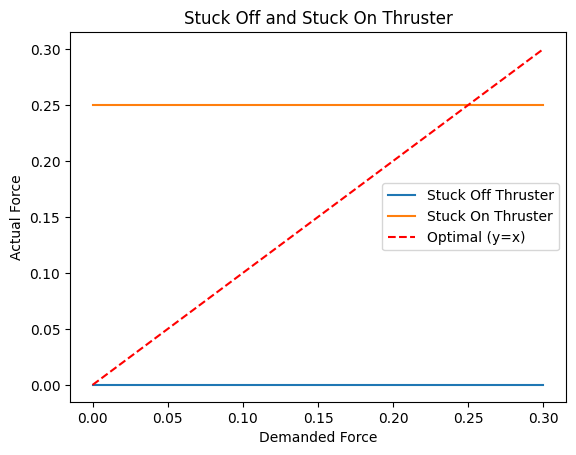

In [17]:
# Main function to create and plot the GPs for the failure models
def model_thruster_failures():
    # Set up the likelihood and training data for different failures
    failure_modes = {
        "Saturated Thrust": {
            "kernel": "Matern",
            "valve_min": None,
            "valve_max": None,
            "lengthscale": 0.1,
            "outputscale": 0.1,
        },
        "Faulty Valve": {
            "kernel": "Matern",
            "valve_min": 0.0,
            "valve_max": 0.3,
            "lengthscale": 0.3,
            "outputscale": 0.4,
        },
        "Thrust Instability": {
            "kernel": "Matern",
            "valve_min": None,
            "valve_max": None,
            "lengthscale": 0.15,
            "outputscale": 0.5,
        },
        "thermal_stress": {
            "kernel": "Matern",
            "valve_min": None,
            "valve_max": None,
            "lengthscale": 0.15,
            "outputscale": 0.5,
        },
    }

    num_points = 100
    num_samples = 2
    subset_size = 40  # Choose how many points you want in the subset

    upper_bound = 0.3
    x_test = torch.linspace(0, upper_bound, 100)

    for failure_type, params in failure_modes.items():
        demanded_force, actual_force = generate_failure_data(
            failure_type,
            num_points=num_points,
            valve_min=params.get("valve_min", 0.1),
            valve_max=params.get("valve_max", 0.8),
            upper_bound=upper_bound
        )

        # Chose a subset of point pairs
        indices = np.random.choice(
            range(1, num_points - 1), size=subset_size - 2, replace=False
        )  # Exclude first and last points
        indices = np.concatenate(
            ([0], indices, [num_points - 1])
        )  # Include first and last points
        indices = np.sort(indices)

        # Use the selected indices to get the subset of points
        demanded_force_subset = demanded_force[indices]
        actual_force_subset = actual_force[indices]

        # Initialize likelihood and model with the specified kernel and set hyperparameters directly
        likelihood = gpytorch.likelihoods.GaussianLikelihood()
        likelihood.noise = torch.tensor(1e-4)
        model = ThrusterFailureGPModel(
            demanded_force_subset,
            actual_force_subset,
            likelihood,
            kernel_type=params["kernel"],
            lengthscale=params["lengthscale"],
            outputscale=params["outputscale"],
        )

        # No training; we set the hyperparameters manually

        # Plot the GP and sampled functions
        model.eval()
        likelihood.eval()

        with torch.no_grad():
            observed_pred = model(x_test)
            lower, upper = observed_pred.confidence_region()

        # Plotting
        plt.figure()
        plt.plot(demanded_force_subset.numpy(), actual_force_subset.numpy(), "k*")
        plt.plot(x_test, observed_pred.mean.numpy(), "b")
        plt.fill_between(x_test, lower.numpy(), upper.numpy(), alpha=0.5)
        plt.plot(
            demanded_force_subset.numpy(), demanded_force_subset.numpy(), "r--"
        )  # Plot y=x for optimal mapping
        plt.title(f"Thruster Failure: {failure_type.capitalize()}")
        plt.legend(["Training Data", "Mean", "Confidence", "Optimal (y=x)"])
        plt.xlabel("Demanded Force")
        plt.ylabel("Actual Force")

        # Sample from the GP and plot the sampled functions
        sampled_functions = sample_gp_function(
            model, likelihood, x_test, num_samples=num_samples
        )
        for i in range(num_samples):
            plt.plot(x_test, sampled_functions[i].numpy(), "--")

        plt.show()

        test = FaultyValve(None)
        test.register_perturbation(index=2, start_time=5.0, x_data=x_test, y_data=sampled_functions[0].numpy())
        test.register_perturbation(index=3, start_time=6.0, x_data=x_test, y_data=sampled_functions[1].numpy())

        # input = np.random.rand(12)
        # print(input)

        # input_perturbed = test.apply(input, timestamp=5.1)
        # print(input_perturbed)

        # #######################

        # input = np.random.rand(12)
        # print(input)

        # input_perturbed = test.apply(input, timestamp=6.1)
        # print(input_perturbed)

        # print("Test")

    # Plot stuck off and stuck on
    plt.figure()
    plt.plot(x_test.numpy(), np.zeros_like(x_test.numpy()), "-", label="Stuck Off Thruster")
    plt.plot(x_test.numpy(), 0.25 * np.ones_like(x_test.numpy()), "-", label="Stuck On Thruster")
    plt.plot(
        demanded_force_subset.numpy(), demanded_force_subset.numpy(), "r--"
    )  # Plot y=x for optimal mapping
    plt.title(f"Stuck Off and Stuck On Thruster")
    plt.legend(["Stuck Off Thruster", "Stuck On Thruster", "Optimal (y=x)"])
    plt.xlabel("Demanded Force")
    plt.ylabel("Actual Force")


if __name__ == "__main__":
    model_thruster_failures()

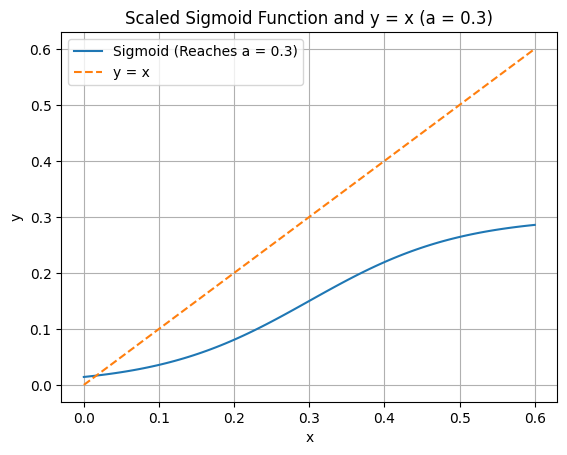

In [16]:
def scaled_sigmoid_torch(x, a=0.3):
    # Custom sigmoid function that is 0 at x=0 and reaches 'a' at x=0.6
    y = a * torch.sigmoid(10 * (x - 0.3))
    return y

# Define x range between 0 and 0.6
x = torch.linspace(0, 0.6, 100)

# Set the target value 'a' at x=0.6
a_value = 0.3  # Change this to your desired value
y_sigmoid = scaled_sigmoid_torch(x, a=a_value)

# Plot y = x line
y_linear = x

# Convert to numpy for plotting
x_np = x.numpy()
y_sigmoid_np = y_sigmoid.detach().numpy()
y_linear_np = y_linear.numpy()

# Plot the sigmoid function and y = x line
plt.plot(x_np, y_sigmoid_np, label=f'Sigmoid (Reaches a = {a_value})')
plt.plot(x_np, y_linear_np, label='y = x', linestyle='--')

# Add labels and legend
plt.title(f'Scaled Sigmoid Function and y = x (a = {a_value})')
plt.xlabel('x')
plt.ylabel('y')
plt.grid(True)
plt.legend()

# Show the plot
plt.show()